In [1]:
# basic vector, dataframe, network processing libraries 
import networkx as nx
import numpy as np 
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# optimal transport 
import ot               # POT library
import got              # Custom wrapper from `got.py` built on top of POT 
import gower            # Species-level trait distance computation for Fused Gromov-Wasserstein

# set the random seed for reproducibility
SEED = 42
# set to True if you want to save the results
SAVE_RESULTS = True
# determine whether the linkage order is by predation (predator -> prey) or by energy flow (prey -> predator)
PREDATION = True
# figure settings 
DPI = 100   # resolution

## 1. Constructing the meta web

This subsection constructs the metaweb, i.e. a network of all species interactions. Individual food webs are then build by taking subgraphs of this metaweb, keeping only the species present at a particular site and any relationships between these species. 

In [3]:
# Begin by importing all of the datasets necessary to construct the meta 
og_species_traits = pd.read_csv(f"functional_traits.csv")                                  # documents the functional traits of every species
species_interaction_df = pd.read_csv("Africa_metaweb_above500.csv", index_col=0)                  # documents the predation patterns across species 
print("Dataset dimensions:", og_species_traits.shape, species_interaction_df.shape)


# Conduct a filtration for species above 500g
species_to_keep = og_species_traits[og_species_traits["Mass.g"] >= 500].Species.values
og_species_traits.set_index("Species", inplace=True)
og_species_traits = og_species_traits.loc[species_to_keep, :]

species_interaction_df = species_interaction_df.loc[species_to_keep, species_to_keep]

Dataset dimensions: (277, 15) (258, 258)


In [4]:
# Showcasing the functional trait dataset 
og_species_traits

,Mass.g,Vertebrate,Mammal,Bird,Herptile,Fish,Invertebrate,Seed,Fruit,Nectar,Root,Woody,Herbaceous,Other
Species,,,,,,,,,,,,,,
Potamogale_velox,660.0,3,0,0,3,3,3,0,0,0,0,0,0,0
Addax_nasomaculatus,70000.3,0,0,0,0,0,0,0,0,0,0,0,3,0
Aepyceros_melampus,52500.1,0,0,0,0,0,0,0,0,0,0,3,3,0
Alcelaphus_buselaphus,171001.5,0,0,0,0,0,0,0,0,0,0,0,3,0
Ammotragus_lervia,48000.0,0,0,0,0,0,0,0,0,0,0,3,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Xerus_inauris,529.0,3,0,0,0,0,3,3,3,0,3,0,0,0
Tachyoryctes_macrocephalus,597.0,0,0,0,0,0,0,0,0,0,3,0,0,0
Thryonomys_gregorianus,2707.1,0,0,0,0,0,0,3,3,0,0,0,3,3


In [5]:
# convert all non-zero values to 1
species_interaction_df = species_interaction_df.map(lambda x: 1 if x != 0 else 0)
# transpose the species_interaction_df
if PREDATION:
    species_interaction_df = species_interaction_df.T
# construct the metaweb in NetworkX
metaweb = nx.from_pandas_adjacency(species_interaction_df, create_using=nx.DiGraph)
species_interaction_df
# UNCOMMENT to visualize the metaweb
# gv.three(metaweb, use_node_size_normalization=True, edge_curvature=0.3)

Prey_Species,Potamogale_velox,Addax_nasomaculatus,Aepyceros_melampus,Alcelaphus_buselaphus,Ammotragus_lervia,Antidorcas_marsupialis,Beatragus_hunteri,Capra_walie,Cephalophus_adersi,Cephalophus_callipygus,...,Cricetomys_gambianus,Pedetes_capensis,Pedetes_surdaster,Epixerus_ebii,Protoxerus_stangeri,Xerus_inauris,Tachyoryctes_macrocephalus,Thryonomys_gregorianus,Thryonomys_swinderianus,Orycteropus_afer
Potamogale_velox,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Addax_nasomaculatus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aepyceros_melampus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alcelaphus_buselaphus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ammotragus_lervia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Xerus_inauris,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Tachyoryctes_macrocephalus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Thryonomys_gregorianus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Thryonomys_swinderianus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
og_species_traits["Plant"] = og_species_traits["Seed"] + og_species_traits["Fruit"] + og_species_traits["Nectar"] + og_species_traits["Root"] + og_species_traits["Woody"] 
og_species_traits["Plant"] = og_species_traits["Plant"].map(lambda x: 1 if x > 0 else 0)
body_mass = og_species_traits.loc[:, ["Mass.g"]]
diet_df = og_species_traits.drop(columns=["Mass.g"])

In [8]:
finalized_region_df = pd.read_csv("Final_Regions_and_Predictors.csv", index_col=0)            # finalized listing of regions, containing subrealms and regions to exclude
finalized_region_df

,Region,Remove,Community,Full_Name,Country,Long,Lat,BioregionName,SubRealm,num_nodes,EVI_mean,bin.AG.class,EVI_std,Frag_std
Code,,,,,,,,,,,,,,
ABER,Lake Turkana,0,Aberdare,Aberdare National Park,Kenya,36.68,-0.38,"Lake Turkana-Sudd Grasslands, Bushlands & Forests",HornOfAfrica,67,3022.374134,99.790611,130.345695,0.000000
AIHS,Southern Drylands,0,Ai Ais,Ai Ais Hot Springs National Park,Namibia,17.33,-27.85,Southwest African Coastal Drylands,SouthernAfroTropics,33,554.515012,99.824253,26.370608,0.000000
AKA,Victoria Basin & Albertine Rift Forests,0,Akagera,Akagera National Park,Rwanda,30.71,-1.64,Victoria Basin & Albertine Rift Forests,EquatorialAfrotropics,73,3120.034642,99.133761,215.289389,0.093841
AMB,Lake Turkana,0,Amboseli,Amboseli National Park,Kenya,37.24,-2.64,"Lake Turkana-Sudd Grasslands, Bushlands & Forests",HornOfAfrica,56,1396.912240,99.801193,229.369004,0.518826
ARAW,Lake Turkana,0,Arawale,Arawale National Reserve,Kenya,40.15,-1.41,"Lake Turkana-Sudd Grasslands, Bushlands & Forests",HornOfAfrica,33,2315.581986,98.668350,59.419183,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WBP,Southern Drylands,0,Waterberg Plateau,Waterberg Plateau National Park,Namibia,17.29,-20.40,Greater Karoo & Kalahari Drylands,SouthernAfroTropics,46,2147.394919,99.829515,106.522372,0.000000
WLNP,Subequatorial Savannas & Woodlands,0,West Lunga,West Lunga National Park,Zambia,24.78,-12.81,Greater African Subequatorial Savannas & Mixed...,SubEquatorialAfrotropics,56,4005.831409,99.814916,106.038267,0.000000
WNP,Sudanian Savanna,0,W,W National Park,Burkina Faso,2.16,11.90,West Sudanian Savanna,SubSaharanAfrotropics,50,2779.939954,96.338223,75.402923,4.061197


In [9]:
subrealms_df = pd.DataFrame(finalized_region_df[finalized_region_df.Remove == 0].set_index("Community").loc[:, "SubRealm"])
loc2subrealms = subrealms_df.to_dict()["SubRealm"]
unique_subrealms = set(loc2subrealms.values())

subrealms_df

,SubRealm
Community,
Aberdare,HornOfAfrica
Ai Ais,SouthernAfroTropics
Akagera,EquatorialAfrotropics
Amboseli,HornOfAfrica
Arawale,HornOfAfrica
...,...
Waterberg Plateau,SouthernAfroTropics
West Lunga,SubEquatorialAfrotropics
W,SubSaharanAfrotropics


In [10]:
regions_df = pd.DataFrame(finalized_region_df[finalized_region_df.Remove == 0].set_index("Community").loc[:, "Region"])
loc2regions = regions_df.to_dict()["Region"]
unique_regions = set(loc2regions.values())

print("Unique regions:", len(unique_regions))
regions_df

Unique regions: 6


,Region
Community,
Aberdare,Lake Turkana
Ai Ais,Southern Drylands
Akagera,Victoria Basin & Albertine Rift Forests
Amboseli,Lake Turkana
Arawale,Lake Turkana
...,...
Waterberg Plateau,Southern Drylands
West Lunga,Subequatorial Savannas & Woodlands
W,Sudanian Savanna


The `Common_Names_Mammals.csv` file contains the common names for each of the organisms. 

In [11]:
common_names = pd.read_csv(f"Common_Names_Mammals.csv")
common_names.set_index("Species", inplace=True)
common_names.index = common_names.index.str.strip()
common_names = common_names.loc[species_to_keep, ["Common_Name"]]
# replace the "_" with " " in the Common_Name entry
common_names["Common_Name"] = common_names["Common_Name"].str.replace("_", " ")
common_names

,Common_Name
Species,
Potamogale_velox,Giant otter shrew
Addax_nasomaculatus,Addax
Aepyceros_melampus,Impala
Alcelaphus_buselaphus,Hartebeest
Ammotragus_lervia,Barbary sheep
...,...
Xerus_inauris,Cape ground squirrel
Tachyoryctes_macrocephalus,Big headed african mole rat
Thryonomys_gregorianus,Lesser cane rat


In [12]:
# subselect the features to use for species-level features
species_traits = og_species_traits.copy()
features = ["Vertebrate", "Invertebrate", "Mammal", "Plant"]
species_traits = species_traits[features]
species_traits

,Vertebrate,Invertebrate,Mammal,Plant
Species,,,,
Potamogale_velox,3,3,0,0
Addax_nasomaculatus,0,0,0,0
Aepyceros_melampus,0,0,0,1
Alcelaphus_buselaphus,0,0,0,0
Ammotragus_lervia,0,0,0,1
...,...,...,...,...
Xerus_inauris,3,3,0,1
Tachyoryctes_macrocephalus,0,0,0,1
Thryonomys_gregorianus,0,0,0,1


In [13]:
finalized_region_list = finalized_region_df[finalized_region_df.Remove == 0].Community
finalized_region_list

Code
ABER             Aberdare
AIHS               Ai Ais
AKA               Akagera
AMB              Amboseli
ARAW              Arawale
              ...        
WBP     Waterberg Plateau
WLNP           West Lunga
WNP                     W
ZAK               Zakouma
ZIN                Zinave
Name: Community, Length: 127, dtype: object

In [14]:
# load in the species site occurence data
species_site_occurence = pd.read_csv("above_500_PA_data.csv", index_col=0)                    # documents the occurence of each species across sites
# map the code names to region names
code_to_name = dict(zip(finalized_region_df.index, finalized_region_df["Community"]))
# the columns are keys to the code_to_name mapping, replace the columns with region names
species_site_occurence.columns = [code_to_name[code] for code in species_site_occurence.columns]
# filter out for only the >500g species and regions in the finalized list
species_site_occurence = species_site_occurence.loc[species_to_keep, finalized_region_list]
species_site_occurence

,Aberdare,Ai Ais,Akagera,Amboseli,Arawale,Arly Partial,Arly Total,Arusha,Bahr Salamat,Bale,...,Tarangire,Tsavo,Tsoulou,Vwaza Marsh,Volcans,Waterberg Plateau,West Lunga,W,Zakouma,Zinave
Species,,,,,,,,,,,,,,,,,,,,,
Potamogale_velox,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
Addax_nasomaculatus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aepyceros_melampus,1,0,1,1,0,0,0,1,0,0,...,1,1,0,1,0,0,1,0,0,1
Alcelaphus_buselaphus,0,0,0,1,0,1,1,1,1,0,...,1,1,0,1,0,1,1,1,1,0
Ammotragus_lervia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Xerus_inauris,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Tachyoryctes_macrocephalus,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Thryonomys_gregorianus,1,0,1,0,0,0,0,1,0,0,...,1,1,0,1,1,0,0,0,0,0


In [15]:
# scale this to produce a dictionary (map) of sites and the realized web at that site
loc2webs = {}
loc2webs_no_subgraph = {}
for site in species_site_occurence.columns:
    species = species_site_occurence[site]
    # subset the non-zero species 
    species = np.array(species[species != 0].index)
    # extract the subgraph with these species from the metaweb
    realize_web = metaweb.subgraph(species)
    # subset to largest weakly connected component 
    subset = max(nx.weakly_connected_components(realize_web), key=len)
    realize_web = realize_web.subgraph(subset)
    # add to the dictionary
    loc2webs[site] = realize_web
    loc2webs_no_subgraph[site] = nx.DiGraph(realize_web)

## 2. Fused Gromov-Wasserstein Distances & Transport Plans

In [16]:
def compute_fused(site1, site2, M, alpha = 0.5, random_state = SEED): 
    got1 = got.GraphOT(loc2webs[site1], "uniform", "shortest_path", filter_lcc=True)
    got2 = got.GraphOT(loc2webs[site2], "uniform", "shortest_path", filter_lcc=True)
    fused_T, log = ot.fused_gromov_wasserstein(M.to_numpy(), got1.get_cost(), got2.get_cost(), 
                                         got1.get_node_dist(), got2.get_node_dist(), log=True, alpha=alpha, random_state=random_state)
    fgw = log["fgw_dist"]
    fused_T = pd.DataFrame(fused_T, index=np.array(M.index), columns=np.array(M.columns))
    return fused_T, fgw

def vis_fused_T(fused_T, title,  
                use_common_names = True, 
                label_same_matches = False): 
    plt.figure(figsize=(15, 15))
    plt.title(title, fontsize = 15)
    fused_T = fused_T.copy()
    # label with common names 
    if use_common_names: 
        fused_T.index = fused_T.index.map(common_names.to_dict()["Common_Name"])
        fused_T.columns = fused_T.columns.map(common_names.to_dict()["Common_Name"])
    # replace the "_" with " " in the index and columns 
    fused_T.index = fused_T.index.str.replace("_", " ")
    fused_T.columns = fused_T.columns.str.replace("_", " ")
    sns.heatmap(fused_T, cmap="Blues", linewidth = 0.05, linecolor="black")
    if label_same_matches: 
        # label the correct matches 
        xticklabels = plt.gca().get_xticklabels()
        yticklabels = plt.gca().get_yticklabels()
        for i, label in enumerate(xticklabels):
            for j, label2 in enumerate(yticklabels): 
                if label.get_text() == label2.get_text():
                    if fused_T.iloc[j, i] > 0: 
                        label.set_color('green')
                        label2.set_color('green')
                    else: 
                        label.set_color('blue')
                        label2.set_color('blue')

In [17]:
def get_gower(site1, site2, loc2webs, species_traits, 
              scale = 1, use_common_names = False): 
    site1_traits = species_traits.loc[np.array(loc2webs[site1].nodes())].astype(float)
    site2_traits = species_traits.loc[np.array(loc2webs[site2].nodes())].astype(float)
    M = gower.gower_matrix(site1_traits, site2_traits)
    M_df = pd.DataFrame(M, index=site1_traits.index, columns=site2_traits.index)
    if use_common_names: 
        M_df.index = M_df.index.map(common_names.to_dict()["Common_Name"])
        M_df.columns = M_df.columns.map(common_names.to_dict()["Common_Name"])
    return M_df * scale

def vis_M(M, title, ylabel, xlabel, use_common_names = False, 
          sort = False, sort_by=body_mass, key = "Mass.g", ): 
    M = M.copy()
    plt.figure(figsize=(12, 12))
    plt.title(title, fontsize = 12)
    if sort and sort_by is not None and key is not None: 
        sorted_index = sort_by.loc[M.index].sort_values(key).index
        sorted_col = sort_by.loc[M.columns].sort_values(key).index
        M = M.loc[sorted_index, sorted_col]
    if use_common_names: 
        M.index = M.index.map(common_names.to_dict()["Common_Name"])
        M.columns = M.columns.map(common_names.to_dict()["Common_Name"])
    # replace the "_" with " " in the index and columns 
    M.index = M.index.str.replace("_", " ")
    M.columns = M.columns.str.replace("_", " ")
    sns.heatmap(M, cmap="Blues", linewidth = 0.5, linecolor="black")
    plt.xlabel(xlabel)
    plt.xticks(fontsize=10)
    plt.ylabel(ylabel)
    plt.xticks(fontsize=10)
   

In [18]:
# compute a dictionary of Gower dissimilarity matrix -- one for each pair of locations 
loc2gower = {}
for site1 in loc2webs: 
    for site2 in loc2webs: 
        gower_diss = get_gower(site1, site2, loc2webs, species_traits, scale=1000)
        loc2gower[(site1, site2)] = gower_diss
        loc2gower[(site2, site1)] = gower_diss.T 

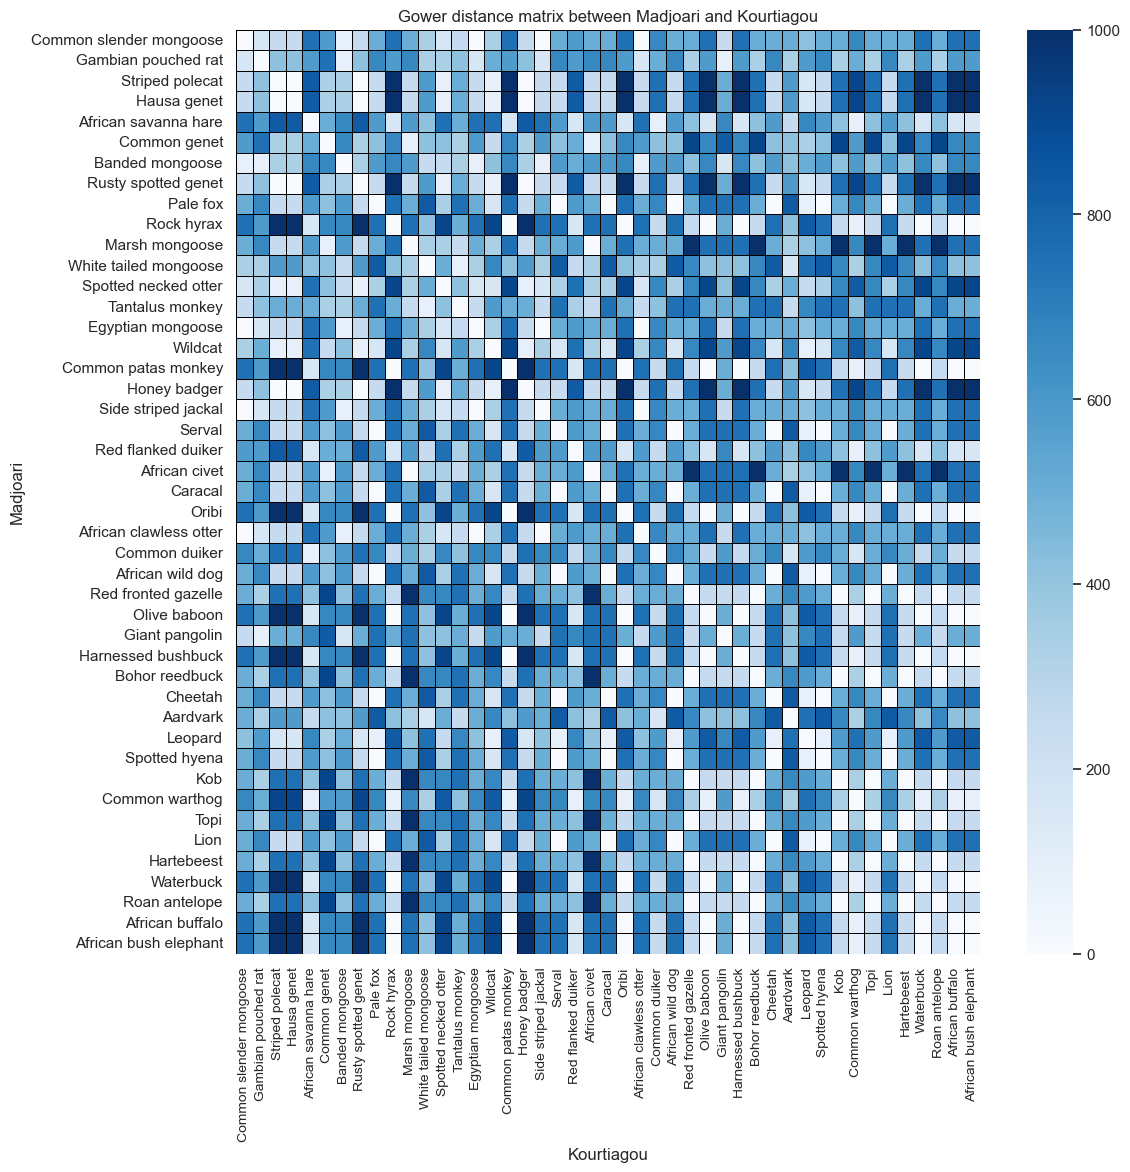

In [19]:
site1 = "Madjoari"
site2 = "Kourtiagou"
vis_M(loc2gower[(site1, site2)], f"Gower distance matrix between {site1} and {site2}", site1, site2, 
      use_common_names=True, sort=True)

Compute the pairwise FGW distance and transport matrices using alpha = 0.5. The first cell below is to do a fresh computation. 

The second cell is to read in the CSV that is used to perform the analysis for our paper. In general, there will be small numerical differences across runs to compute the FGW distance, since each of those are their own optimization problems. 

In [ ]:
# # TODO: Uncomment to compute the pairwise OT matrix from scratch -- this takes around a minute. 
# # NOTE: Exact numbers make look slightly different from run to run due to numerical instability. 
webs_ot = got.GraphOT_Factory(loc2webs, "uniform", "shortest_path", filter_lcc=True)
pairwise_fgw, _ = webs_ot.compute_pairwise_mat(random_seed=SEED, mode="FGW", feature_mat=loc2gower, alpha=0.5)
pairwise_fgw.to_csv("pairwise_fgw.csv")

In [ ]:
pairwise_fgw = pd.read_csv("pairwise_fgw.csv", index_col=0)
# make sure we subset to the 127 sites that are relevant. 
selected_sites = loc2webs.keys()
pairwise_fgw = pairwise_fgw.loc[selected_sites, selected_sites]   
pairwise_fgw

## 3. Load in the provided Fused-GW

We notice that across different runs of the Fused Gromov-Wasserstein compute code.

Such issues may due to differences in package version, the operating systems that we are running on, a stochastic portion in our `got.py` script that we did not set the seed for, or even a non-determinancy in the official Python Optimal Transport (POT), which we built upon. 

The code we are referring to is 
```
pairwise_fgw, _ = webs_ot.compute_pairwise_mat(random_seed=SEED, mode="FGW", feature_mat=loc2gower, alpha=0.5)
```

To demonstrate that such numercial issues likely have minimal effect on the results, we collect the percentage difference of the Fused GW computations of fresh runs relative to our provided file to show that the differences are, on average, extremely small. 

In [ ]:
CLONES = 2
percentage_differences = []
webs_ot = got.GraphOT_Factory(loc2webs, "uniform", "shortest_path", filter_lcc=True)
for _ in range(CLONES):
    pairwise_fgw_clone, _ = webs_ot.compute_pairwise_mat(random_seed=SEED, mode="FGW", feature_mat=loc2gower, alpha=0.5)
    diff = (pairwise_fgw - pairwise_fgw_clone) / (pairwise_fgw)
    percentage_differences.append(diff.abs().mean().mean() * 100)

print("Average percentage difference over 10 runs:") 
print("        Mean:", round(np.mean(percentage_differences), 2), "%")
print("     Std Dev:", round(np.std(percentage_differences), 2), "%")